In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\mirza\Documents\ftir_ml_ready.csv")

df.head()

,sample,4000,3999,3998,3997,3996,3995,3994,3993,3992,...,459,458,457,456,455,454,453,452,451,450
0,A_esculenta_1_1,0.0045,0.0045,0.0045,0.0046,0.0046,0.0046,0.0046,0.0046,0.0046,...,0.0042,0.0035,0.0033,0.0035,0.0036,0.0032,0.0023,0.0013,0.0005,-0.0001
1,A_esculenta_2_1,0.0037,0.0037,0.0037,0.0037,0.0037,0.0037,0.0037,0.0037,0.0037,...,0.0087,0.0079,0.0071,0.0065,0.0062,0.0059,0.0057,0.0054,0.0046,0.0032
2,A_esculenta_3_1,0.0041,0.0041,0.0041,0.0041,0.0041,0.0042,0.0042,0.0042,0.0042,...,0.0050,0.0043,0.0037,0.0038,0.0042,0.0042,0.0039,0.0033,0.0027,0.0018
3,A_esculenta_4_1,0.0047,0.0047,0.0046,0.0046,0.0047,0.0047,0.0047,0.0047,0.0047,...,0.0067,0.0055,0.0046,0.0043,0.0043,0.0042,0.0042,0.0043,0.0042,0.0035
4,A_taxiformis_1_001_1,0.0071,0.0071,0.0071,0.0071,0.0071,0.0071,0.0071,0.0071,0.0071,...,0.0091,0.0093,0.0094,0.0093,0.0091,0.0086,0.0078,0.0072,0.0069,0.0069


In [3]:
# sample column
samples = df["sample"]

# spectral matrix
X = df.drop(columns=["sample"])

# convert to numeric
X = X.astype(float)

In [4]:
X_norm = (X - X.min()) / (X.max() - X.min())

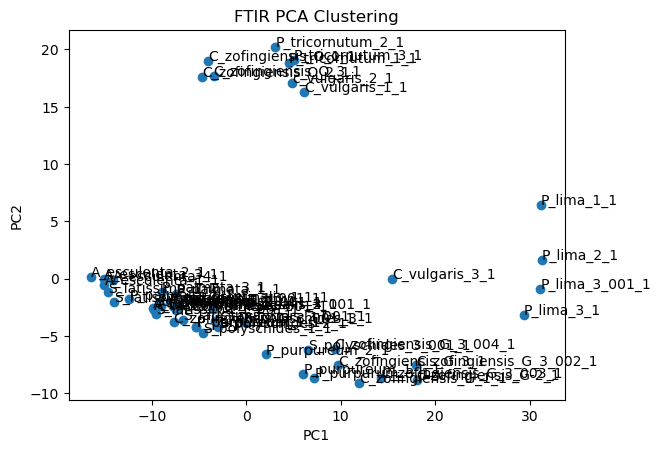

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_norm)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1])

for i, txt in enumerate(samples):
    plt.annotate(txt, (X_pca[i,0], X_pca[i,1]))

plt.title("FTIR PCA Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [7]:
from sklearn.ensemble import RandomForestClassifier

y = samples   # use existing sample labels

rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_norm, y)

importance = rf.feature_importances_
wavenumbers = X.columns

importance_df = pd.DataFrame({
    "wavenumber": wavenumbers,
    "importance": importance
})

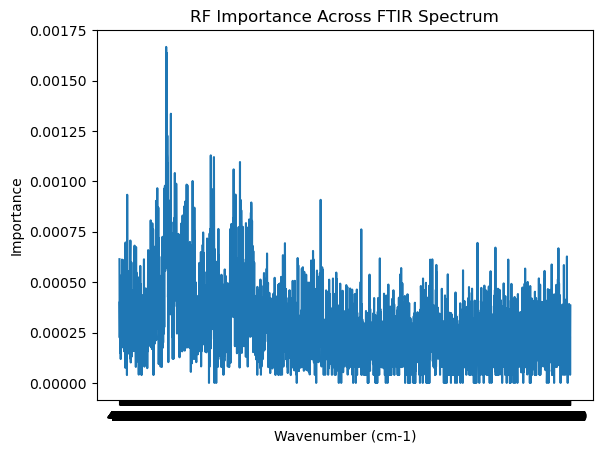

In [8]:
plt.figure()
plt.plot(importance_df["wavenumber"], importance_df["importance"])
plt.gca().invert_xaxis()
plt.title("RF Importance Across FTIR Spectrum")
plt.xlabel("Wavenumber (cm-1)")
plt.ylabel("Importance")
plt.show()

In [9]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
Y = lb.fit_transform(y)

pls = PLSRegression(n_components=2)
X_pls = pls.fit_transform(X_norm, Y)[0]

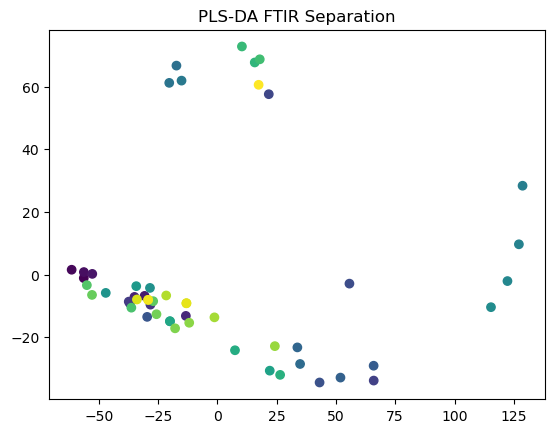

In [10]:
plt.figure()
plt.scatter(X_pls[:,0], X_pls[:,1], c=pd.factorize(y)[0])
plt.title("PLS-DA FTIR Separation")
plt.show()

In [11]:
from scipy.signal import find_peaks

# mean spectrum
mean_spec = X_norm.mean(axis=0).values

peaks, _ = find_peaks(mean_spec, height=np.mean(mean_spec))

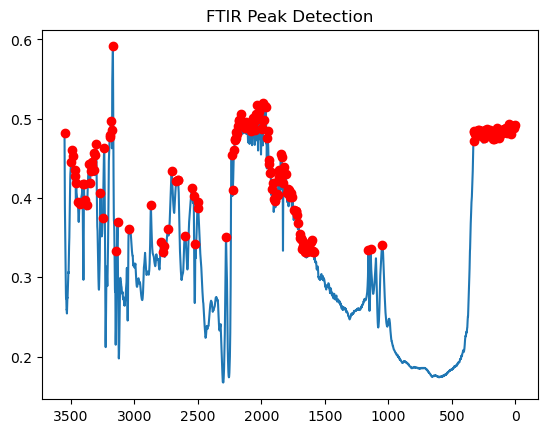

In [12]:
plt.figure()
plt.plot(mean_spec)

plt.plot(peaks, mean_spec[peaks], "ro")

plt.gca().invert_xaxis()
plt.title("FTIR Peak Detection")
plt.show()

In [13]:
from scipy.ndimage import gaussian_filter1d

smooth_spec = gaussian_filter1d(mean_spec, sigma=2)

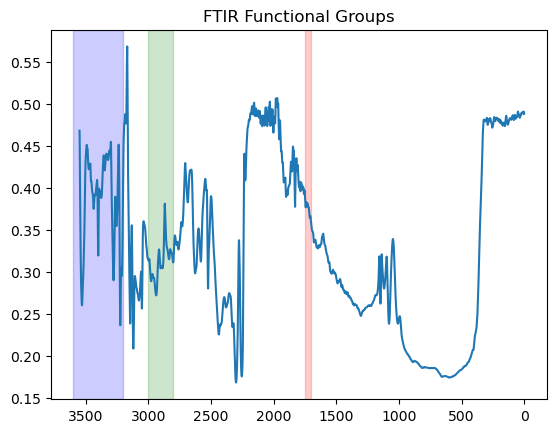

In [14]:
plt.figure()
plt.plot(smooth_spec)
plt.gca().invert_xaxis()

plt.axvspan(3200, 3600, color='blue', alpha=0.2)  # OH
plt.axvspan(2800, 3000, color='green', alpha=0.2) # CH
plt.axvspan(1700, 1750, color='red', alpha=0.2)   # C=O

plt.title("FTIR Functional Groups")
plt.show()